#### This notebook demonstrates the use of InFoRM algorithms to mitigate bias for PageRank
InFoRM includes 3 algorithms, namely debiasing the input graph, debiasing the mining model and debiasing the mining result. We will show how to run all 3 algorithms for PageRank in this notebook.

### Get vanilla PageRank vector first

In [1]:
# load necessary packages
import pickle
import load_graph
import utils
import numpy as np
import networkx as nx

from scipy.sparse import csc_matrix

In [2]:
def vanilla(name):
    try:
        with open('result/pagerank/vanilla.pickle', 'rb') as f:
            rdict = pickle.load(f)
    except:
        rdict = dict()

    if name == 'ppi':
        data = load_graph.read_mat(name)
        adj = data['adjacency']
    else:
        graph = load_graph.read_graph(name)
        adj = nx.to_scipy_sparse_matrix(graph, dtype='float', format='csc')

    adj = utils.symmetric_normalize(adj)
    graph = nx.from_scipy_sparse_array(adj, create_using=nx.Graph())

    r = utils.power_method(graph, c=0.85)
    r = np.array([list(r.values())])
    r = csc_matrix(np.array(r).transpose())
    rdict[name] = r

    with open('result/pagerank/vanilla.pickle', 'wb') as f:
        pickle.dump(rdict, f, protocol=pickle.HIGHEST_PROTOCOL)

In [3]:
# get vanilla PageRank vector
vanilla(name='ppi')

### Let's debias the input graph

In [4]:
# load debias model
import torch
import torch.nn as nn
from method.debias_graph import DebiasGraph

In [5]:
def debias_input_graph(name, c=0.85, alpha=0., lr=0., metric=None):
    if name == 'ppi':
        data = load_graph.read_mat(name)
        init_adj = data['adjacency']
    else:
        graph = load_graph.read_graph(name)
        init_adj = nx.to_scipy_sparse_matrix(graph, dtype='float', format='csc')
    init_adj = utils.symmetric_normalize(init_adj)

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(init_adj, metric=metric), sigma=0.75)
    sim = utils.symmetric_normalize(sim)

    # debias pagerank
    FairGraph = DebiasGraph()
    graph = FairGraph.pagerank(init_adj, sim, alpha, lr=lr, c=c, tol=1e-6, maxiter=100)
    r = utils.power_method(graph, c=c)

    r = np.array([list(r.values())])
    r = csc_matrix(np.array(r).transpose())

    print('dataset: {}\t metric: {} similarity'.format(name, metric))
    print('Finished!')

    return r

In [6]:
# jaccard index
result = dict()
result['ppi'] = debias_input_graph(name='ppi', c=0.85, alpha=1e6, lr=5e-4, metric='jaccard')
with open('result/pagerank/graph/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_input_graph(name='ppi', c=0.85, alpha=1e6, lr=5e-4, metric='cosine')
with open('result/pagerank/graph/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

Debiasing Graph: 100%|██████████| 100/100 [12:58<00:00,  7.79s/it]


dataset: ppi	 metric: jaccard similarity
Finished!


Debiasing Graph: 100%|██████████| 100/100 [14:46<00:00,  8.87s/it]


dataset: ppi	 metric: cosine similarity
Finished!


### Let's debias the mining model

In [7]:
# load debias model
from method.debias_model import DebiasModel

In [8]:
def debias_mining_model(name, alpha=0., metric=None):
    # init params
    c = 0.85

    # load dataset
    if name == 'ppi':
        data = load_graph.read_mat(name)
        adj = data['adjacency']
    else:
        graph = load_graph.read_graph(name)
        adj = nx.to_scipy_sparse_matrix(graph, dtype='float', format='csc')
    adj = utils.symmetric_normalize(adj)

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj, metric=metric), sigma=0.75)
    sim = utils.symmetric_normalize(sim)

    # debias pagerank
    FairModel = DebiasModel()
    r = FairModel.pagerank(adj, sim, alpha, c=c)
    r = np.array([list(r.values())])
    r = csc_matrix(np.array(r).transpose())

    print('dataset: {}\t metric: {} similarity'.format(name, metric))
    print('Finished!')

    return r

In [9]:
alpha = 0.5

# jaccard index
result = dict()
result['ppi'] = debias_mining_model(name='ppi', alpha=alpha, metric='jaccard')
with open('result/pagerank/model/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_model(name='ppi', alpha=alpha, metric='cosine')
with open('result/pagerank/model/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

dataset: ppi	 metric: jaccard similarity
Finished!
dataset: ppi	 metric: cosine similarity
Finished!


### Let's debias the mining result

In [10]:
# load debias model
from method.debias_result import DebiasResult

In [11]:
def debias_mining_result(name, vanilla, alpha=0., metric=None):
    # vanilla result
    r = vanilla[name]

    # load dataset
    if name == 'ppi':
        data = load_graph.read_mat(name)
        adj = data['adjacency']
    else:
        graph = load_graph.read_graph(name)
        adj = nx.to_scipy_sparse_matrix(graph, dtype='float', format='csc')
    adj = utils.symmetric_normalize(adj)

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj, metric=metric), sigma=0.75)
    sim = utils.symmetric_normalize(sim)

    # debias pagerank
    # r = pagerank.debias_result(r, S, lambda_)
    FairResult = DebiasResult()
    r = FairResult.fit(r, sim, alpha)

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return r

In [12]:
alpha = 0.5

with open('result/pagerank/vanilla.pickle', 'rb') as f:
    vanilla = pickle.load(f)

# jaccard index
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='jaccard')
with open('result/pagerank/result/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='cosine')
with open('result/pagerank/result/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

dataset: ppi	metric: jaccard similarity
Finished!
dataset: ppi	metric: cosine similarity
Finished!


### Now, let's see how much we debiased and how good debiased results are

In [13]:
# load evaluation functions
from evaluate.pagerank import *

In [14]:
evaluate(name='ppi', metric='jaccard', task='graph')
evaluate(name='ppi', metric='cosine', task='graph')
evaluate(name='ppi', metric='jaccard', task='model')
evaluate(name='ppi', metric='cosine', task='model')
evaluate(name='ppi', metric='jaccard', task='result')
evaluate(name='ppi', metric='cosine', task='result')

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.18492063442801043), 'kl': np.float64(0.0018969515975970268), 'precision': {50: 0.92}, 'ndcg': {50: np.float64(0.9442572100682158)}, 'bias': np.float64(0.43385507693395464)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.32807729748029574), 'kl': np.float64(0.008071437274667047), 'precision': {50: 0.78}, 'ndcg': {50: np.float64(0.8381436001251663)}, 'bias': np.float64(0.686652500412535)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.21119486360528844), 'kl': np.float64(0.004778336149265419), 'precision': {50: 0.92}, 'ndcg': {50: np.float64(0.9418922547520626)}, 'bias': np.float64(0.5082799234158019)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the mining model', 'diff': np.float64(0.27991281773296933), 'kl': np.float64(0.00956437934504764), 'pr

{'dataset': 'ppi',
 'metric': 'cosine similarity',
 'task': 'debias the mining result',
 'diff': np.float64(0.11192352059618442),
 'kl': np.float64(0.00696792854264369),
 'precision': {50: 0.94},
 'ndcg': {50: np.float64(0.9582718579671627)},
 'bias': np.float64(0.44986224137895925)}

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.18492063442801043), 'kl': np.float64(0.0018969515975970268), 'precision': {50: 0.92}, 'ndcg': {50: np.float64(0.9442572100682158)}, 'bias': np.float64(0.43385507693395464)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.32807729748029574), 'kl': np.float64(0.008071437274667047), 'precision': {50: 0.78}, 'ndcg': {50: np.float64(0.8381436001251663)}, 'bias': np.float64(0.686652500412535)}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.21119486360528844), 'kl': np.float64(0.004778336149265419), 'precision': {50: 0.92}, 'ndcg': {50: np.float64(0.9418922547520626)}, 'bias': np.float64(0.5082799234158019)}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the mining model', 'diff': np.float64(0.27991281773296933), 'kl': np.float64(0.00956437934504764), 'pr

,task,metric,diff,kl,precision,ndcg,bias,label
0,graph,jaccard,0.184921,0.001897,0.92,0.944257,0.433855,graph-jaccard
1,graph,cosine,0.328077,0.008071,0.78,0.838144,0.686653,graph-cosine
2,model,jaccard,0.211195,0.004778,0.92,0.941892,0.508280,model-jaccard
3,model,cosine,0.279913,0.009564,0.90,0.928332,0.674945,model-cosine
4,result,jaccard,0.044607,0.001218,0.94,0.958495,0.270044,result-jaccard
5,result,cosine,0.111924,0.006968,0.94,0.958272,0.449862,result-cosine


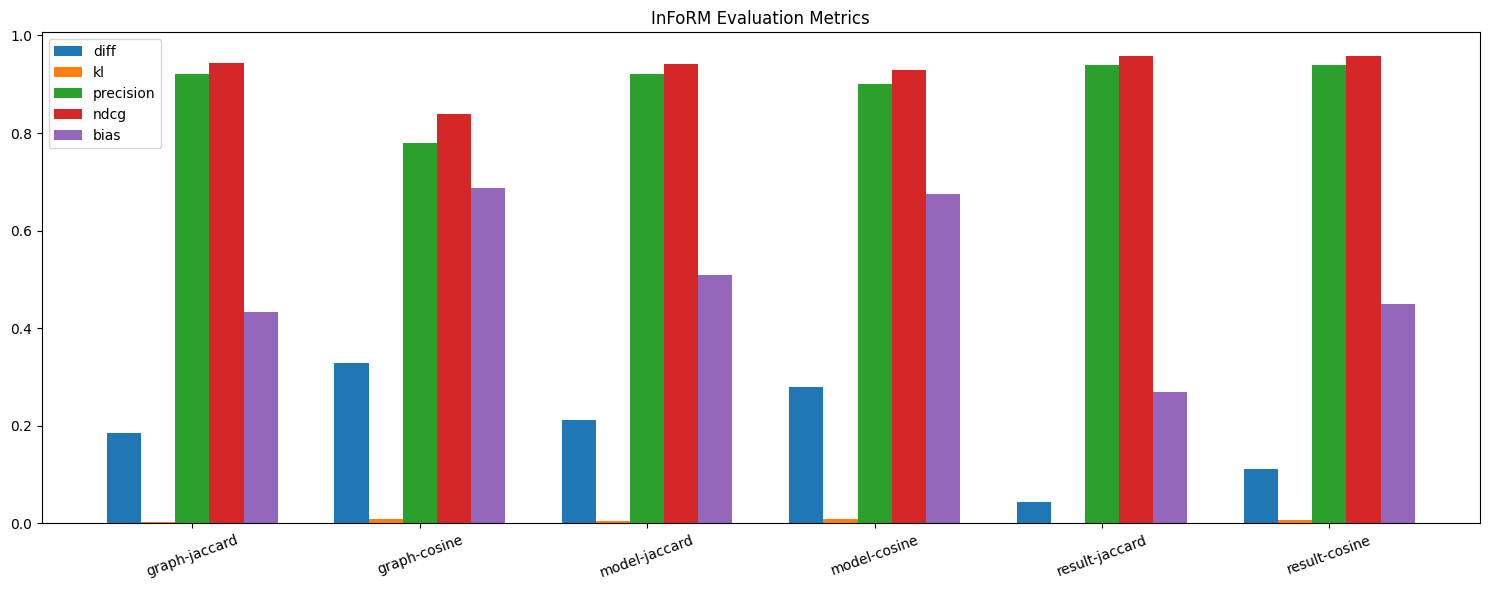

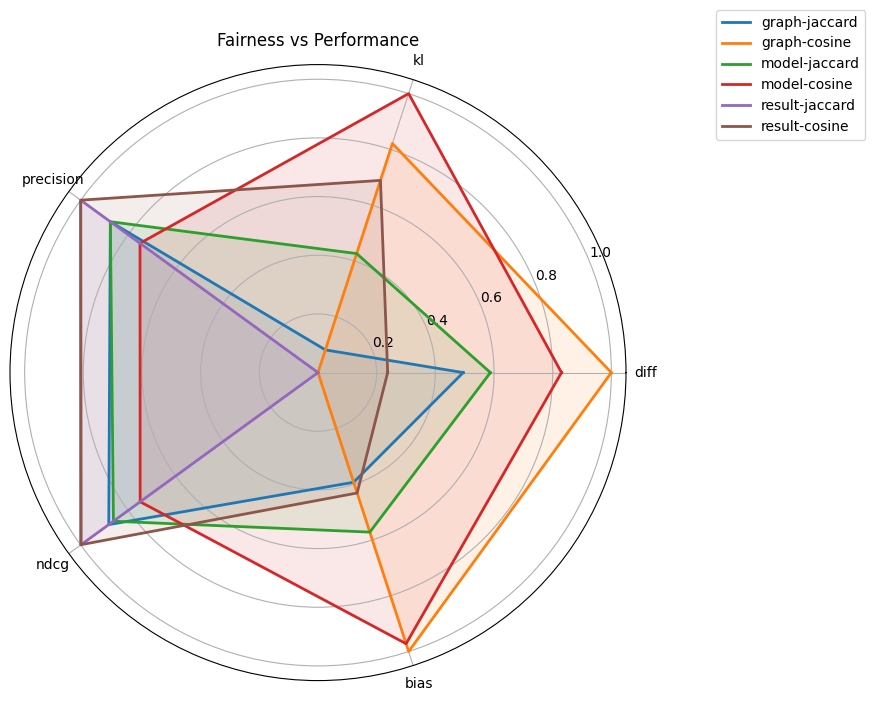

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# RUN EVALUATION
# =========================

results = []

configs = [
    ('jaccard', 'graph'),
    ('cosine', 'graph'),
    ('jaccard', 'model'),
    ('cosine', 'model'),
    ('jaccard', 'result'),
    ('cosine', 'result')
]

for metric, task in configs:
    
    r = evaluate(
        name='ppi',
        metric=metric,
        task=task
    )
    
    row = {
        'task': task,
        'metric': metric,
        'diff': float(r['diff']),
        'kl': float(r['kl']),
        'precision': float(r['precision'][50]),
        'ndcg': float(r['ndcg'][50]),
        'bias': float(r['bias'])
    }
    
    results.append(row)

# =========================
# DATAFRAME
# =========================

df = pd.DataFrame(results)

df['label'] = df['task'] + "-" + df['metric']

display(df)

# =========================
# BAR CHART
# =========================

metrics = ['diff', 'kl', 'precision', 'ndcg', 'bias']

x = np.arange(len(df))
width = 0.15

plt.figure(figsize=(15,6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        df[metric],
        width=width,
        label=metric
    )

plt.xticks(
    x + width*2,
    df['label'],
    rotation=20
)

plt.title("InFoRM Evaluation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# RADAR CHART
# =========================

radar_df = df.copy()

# normalize
for col in metrics:
    radar_df[col] = (
        radar_df[col] - radar_df[col].min()
    ) / (
        radar_df[col].max() - radar_df[col].min()
    )

categories = metrics
N = len(categories)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

for i in range(len(radar_df)):
    
    values = radar_df.loc[i, metrics].tolist()
    values += values[:1]
    
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=radar_df.loc[i, 'label']
    )
    
    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Fairness vs Performance")

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.4, 1.1)
)

plt.show()